# Text associations

Associations between normalized reading times on the **text regions**
(distractor / critical / outside) and on the **answers & question** (A / B / C / D / question).

Data: `L1_model_ready_all_features.csv` (`READY_ALL_FEATURES_PATH`).

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data_paths import READY_ALL_FEATURES_PATH

df = pd.read_csv(READY_ALL_FEATURES_PATH)
print(df.shape)
df.head()

(19436, 208)


,participant_id,TRIAL_INDEX,text_id_with_q,is_correct,area_dwell_proportion__answer_A,area_dwell_proportion__answer_B,area_dwell_proportion__answer_C,area_dwell_proportion__answer_D,area_dwell_proportion__question,first_encounter_avg_pupil_size_z__answer_A,...,TimeSinceOffset_pure_distance_furthest,TimeSinceOffset_pure_distance_closest,TimeSinceOffset_normalized_correct,TimeSinceOffset_normalized_wrong_mean,TimeSinceOffset_normalized_contrast,TimeSinceOffset_normalized_distance_furthest,TimeSinceOffset_normalized_distance_closest,ANSWER_PRESS_NUMBER,total_answering_RT,total_answering_RT_normalized
0,l42_2070,4,3_6_Ele_1_2,1,0.319310,0.213167,0.181306,0.257173,0.029044,0.798335,...,1734.0,251.0,593.000000,602.857143,-9.857143,163.000000,48.857143,1,7330,222.121212
1,l42_2070,5,3_6_Adv_2_2,1,0.244538,0.469212,0.170161,0.116089,0.000000,0.086368,...,1110.0,23.0,106.083333,261.925926,-155.842593,158.694444,153.116667,1,5650,141.250000
2,l42_2070,6,3_6_Ele_3_0,1,0.388110,0.148282,0.349458,0.079114,0.035036,-0.436190,...,2750.0,1584.0,324.500000,277.523810,46.976190,269.500000,179.928571,1,5562,135.658537
3,l42_2070,7,3_6_Adv_4_1,1,0.501591,0.178867,0.126353,0.147995,0.045194,0.590876,...,3599.0,1576.0,404.900000,219.950000,184.950000,359.900000,89.700000,1,4762,136.057143
4,l42_2070,8,3_6_Ele_5_0,1,0.241206,0.370537,0.153399,0.177466,0.057392,-1.167965,...,1748.0,287.0,123.000000,211.171296,-88.171296,264.625000,59.222222,1,4884,103.914894


In [2]:
# Build model-ready features per group (hunters / gatherers) from the processed
# per-group CSVs, saved next to the all-participants file with the group noted.
from src.data_paths import (
    HUNTERS_PROCESSED_PATH,
    GATHERERS_PROCESSED_PATH,
    L1_BASED_DATA_DIR,
)
from src.predictive_modeling.answer_correctness.model_data import save_all_features

GROUP_RAW_PATHS = {
    "hunters": HUNTERS_PROCESSED_PATH,
    "gatherers": GATHERERS_PROCESSED_PATH,
}
GROUP_FEATURE_PATHS = {
    name: L1_BASED_DATA_DIR / f"L1_model_ready_{name}_features.csv"
    for name in GROUP_RAW_PATHS
}

REBUILD = False  # set True to regenerate the per-group feature CSVs
group_dfs = {}
for name, raw_path in GROUP_RAW_PATHS.items():
    feat_path = GROUP_FEATURE_PATHS[name]
    if REBUILD or not feat_path.exists():
        save_all_features(pd.read_csv(raw_path), output_path=feat_path)
    group_dfs[name] = pd.read_csv(feat_path)
    print(name, group_dfs[name].shape)

hunters (9719, 208)
gatherers (9717, 208)


In [3]:
# Reusable cross-correlation heatmap: text regions (rows) vs. answers/question (cols)
REGIONS = ["distractor", "critical", "outside"]
ANSWERS = ["answer_A", "answer_B", "answer_C", "answer_D", "question"]


def region_answer_cross_corr(df, metric):
    """metric in {'RT', 'TFD'} -> 3x5 cross-correlation of normalized values."""
    region_cols = [f"{metric}_normalized_{r}" for r in REGIONS]
    answer_cols = [f"{metric}_normalized_{a}" for a in ANSWERS]
    corr = df[region_cols + answer_cols].corr().loc[region_cols, answer_cols]
    pretty = lambda c: c.replace(f"{metric}_normalized_", "").replace("answer_", "ans ")
    return corr.rename(index=pretty, columns=pretty)


def plot_cross_corr(cc, ax, title):
    im = ax.imshow(cc.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(cc.shape[1]))
    ax.set_xticklabels(cc.columns, rotation=45, ha="right")
    ax.set_yticks(range(cc.shape[0]))
    ax.set_yticklabels(cc.index)
    for i in range(cc.shape[0]):
        for j in range(cc.shape[1]):
            v = cc.values[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    color="white" if abs(v) > 0.5 else "black", fontsize=9)
    ax.set_title(title)
    return im


def plot_group(df, group_label):
    """RT and TFD cross-correlation heatmaps side by side for one group."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, metric in zip(axes, ["RT", "TFD"]):
        cc = region_answer_cross_corr(df, metric)
        im = plot_cross_corr(cc, ax, f"{group_label} — normalized {metric}")
    fig.colorbar(im, ax=axes, label="Pearson r", fraction=0.025)
    fig.suptitle(f"{group_label}: text regions vs. answers/question", y=1.05)
    plt.show()

In [4]:
# Normalized reading-time columns: text regions (rows) vs. answers/question (cols)
text_region_cols = [
    "RT_normalized_distractor",
    "RT_normalized_critical",
    "RT_normalized_outside",
]
answer_cols = [
    "RT_normalized_answer_A",
    "RT_normalized_answer_B",
    "RT_normalized_answer_C",
    "RT_normalized_answer_D",
    "RT_normalized_question",
]

# Full pairwise correlation, then slice to the cross-block (regions x answers/question)
corr = df[text_region_cols + answer_cols].corr()
cross_corr = corr.loc[text_region_cols, answer_cols]

pretty = lambda c: c.replace("RT_normalized_", "").replace("answer_", "ans ").replace("_", " ")
cross_corr_display = cross_corr.rename(index=pretty, columns=pretty)
cross_corr_display.round(3)

,ans A,ans B,ans C,ans D,question
distractor,0.067,0.073,0.117,0.067,0.052
critical,0.126,0.132,0.127,0.125,0.068
outside,0.082,0.074,0.086,0.078,0.050


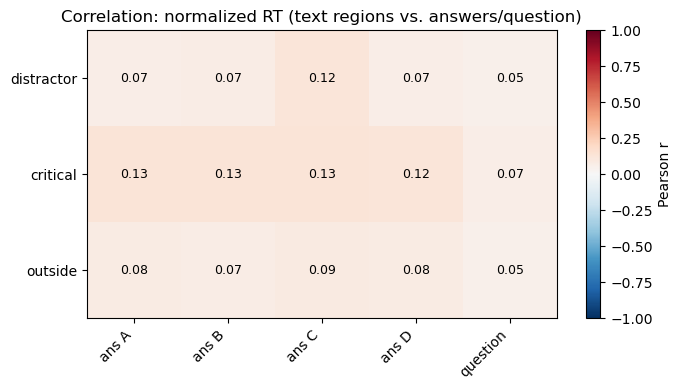

In [5]:
# Heatmap of the cross-correlation block
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(cross_corr_display.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")

ax.set_xticks(range(cross_corr_display.shape[1]))
ax.set_xticklabels(cross_corr_display.columns, rotation=45, ha="right")
ax.set_yticks(range(cross_corr_display.shape[0]))
ax.set_yticklabels(cross_corr_display.index)

for i in range(cross_corr_display.shape[0]):
    for j in range(cross_corr_display.shape[1]):
        v = cross_corr_display.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="white" if abs(v) > 0.5 else "black", fontsize=9)

ax.set_title("Correlation: normalized RT (text regions vs. answers/question)")
fig.colorbar(im, ax=ax, label="Pearson r")
plt.tight_layout()
plt.show()

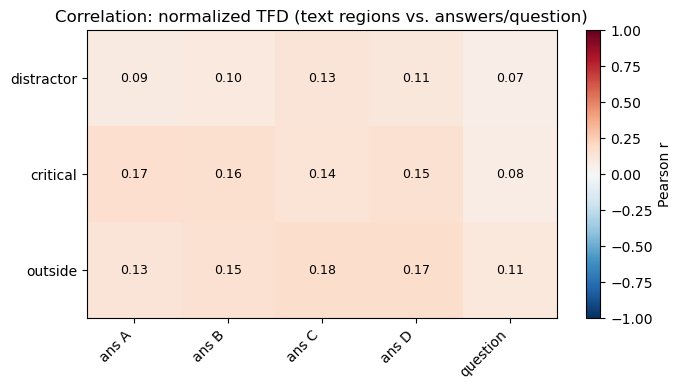

,ans A,ans B,ans C,ans D,question
distractor,0.092,0.095,0.127,0.112,0.066
critical,0.169,0.163,0.139,0.152,0.075
outside,0.132,0.151,0.177,0.173,0.108


In [6]:
# Same cross-correlation for TFD (total fixation duration), normalized
tfd_region_cols = [
    "TFD_normalized_distractor",
    "TFD_normalized_critical",
    "TFD_normalized_outside",
]
tfd_answer_cols = [
    "TFD_normalized_answer_A",
    "TFD_normalized_answer_B",
    "TFD_normalized_answer_C",
    "TFD_normalized_answer_D",
    "TFD_normalized_question",
]

tfd_corr = df[tfd_region_cols + tfd_answer_cols].corr()
tfd_cross_corr = tfd_corr.loc[tfd_region_cols, tfd_answer_cols]

tfd_pretty = lambda c: c.replace("TFD_normalized_", "").replace("answer_", "ans ").replace("_", " ")
tfd_cross_corr_display = tfd_cross_corr.rename(index=tfd_pretty, columns=tfd_pretty)

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(tfd_cross_corr_display.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")

ax.set_xticks(range(tfd_cross_corr_display.shape[1]))
ax.set_xticklabels(tfd_cross_corr_display.columns, rotation=45, ha="right")
ax.set_yticks(range(tfd_cross_corr_display.shape[0]))
ax.set_yticklabels(tfd_cross_corr_display.index)

for i in range(tfd_cross_corr_display.shape[0]):
    for j in range(tfd_cross_corr_display.shape[1]):
        v = tfd_cross_corr_display.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="white" if abs(v) > 0.5 else "black", fontsize=9)

ax.set_title("Correlation: normalized TFD (text regions vs. answers/question)")
fig.colorbar(im, ax=ax, label="Pearson r")
plt.tight_layout()
plt.show()

tfd_cross_corr_display.round(3)

## Per group: hunters vs. gatherers

Same cross-correlations (RT and TFD, normalized) computed separately for each group.

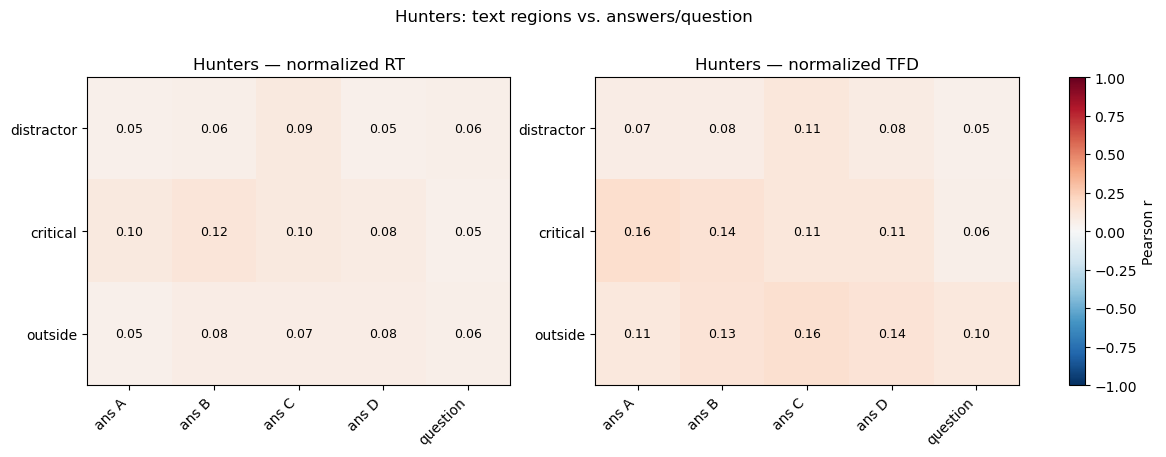

In [7]:
plot_group(group_dfs["hunters"], "Hunters")

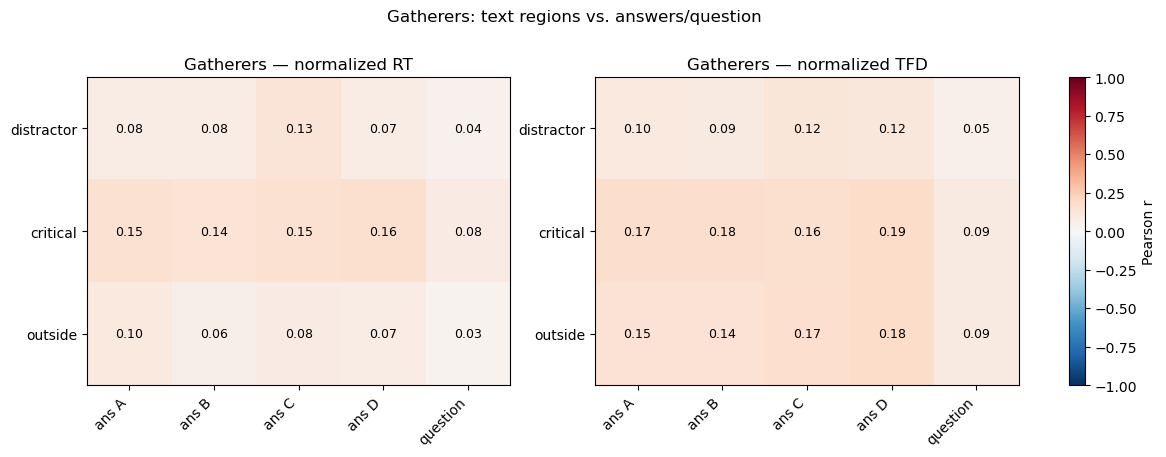

In [8]:
plot_group(group_dfs["gatherers"], "Gatherers")

## Predict answer reading times from paragraph features

One regression per answer (A/B/C/D). Predictors are paragraph-only: per-span area
metrics, per-span RT/TFD (pure + normalized), and the hunter/gatherer preview
flag — no answer-area features. Pick `FEATURE_COLS` to control what goes in.

In [9]:
from src.predictive_modeling.answer_RTs.model_data import (
    build_answer_rt_model_df,
    get_paragraph_feature_cols,
    get_span_area_feature_cols,
    get_span_rt_tfd_feature_cols,
    get_preview_feature_cols,
)
from src.predictive_modeling.answer_RTs.run import run_answer_rt_regression

# Trial-level frame: paragraph predictors + answer-RT targets (built once).
answer_rt_model_df = build_answer_rt_model_df()
print("model df:", answer_rt_model_df.shape)


def plot_true_pred(out, answers=("A", "B", "C", "D")):
    """2x2 held-out true-vs-predicted scatter, coloured by reading regime."""
    fig, axes = plt.subplots(2, 2, figsize=(11, 10))
    target = out["results"][answers[0]]["metrics"]["target"].rsplit("_answer_", 1)[0]
    for ax, ans in zip(axes.ravel(), answers):
        res = out["results"][ans]
        p, m = res["predictions"], res["metrics"]
        if "question_preview" in p.columns:
            for val, lab, c in [(1, "hunter", "tab:orange"), (0, "gatherer", "tab:blue")]:
                s = p[p["question_preview"] == val]
                ax.scatter(s["y_true"], s["y_pred"], s=6, alpha=0.3, color=c, label=lab)
            ax.legend(fontsize=8)
        else:
            ax.scatter(p["y_true"], p["y_pred"], s=6, alpha=0.3)
        lo = float(min(p["y_true"].min(), p["y_pred"].min()))
        hi = float(max(p["y_true"].max(), p["y_pred"].max()))
        ax.plot([lo, hi], [lo, hi], "k--", lw=1)
        ax.set_title(f"answer {ans}:  R²={m['r2']:.3f}   RMSE={m['rmse']:.0f}")
        ax.set_xlabel("true RT")
        ax.set_ylabel("predicted RT")
    fig.suptitle(f"True vs predicted — {target}", y=1.01)
    plt.tight_layout()
    plt.show()


def plot_coefs(out, answers=("A", "B", "C", "D"), top_k=12):
    """2x2 top-|coef| standardized coefficients per answer (features are z-scored)."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for ax, ans in zip(axes.ravel(), answers):
        cs = out["results"][ans]["coef_summary"].head(top_k).iloc[::-1]
        colors = ["tab:red" if v < 0 else "tab:green" for v in cs["coef"]]
        ax.barh(cs["feature"], cs["coef"], color=colors)
        ax.axvline(0, color="k", lw=0.8)
        ax.set_title(f"answer {ans} — top {top_k} |coef|")
        ax.tick_params(labelsize=7)
    plt.tight_layout()
    plt.show()


# --- choose which features to run -------------------------------------------
FEATURE_COLS = get_paragraph_feature_cols(answer_rt_model_df)   # everything (default)
# FEATURE_COLS = get_span_rt_tfd_feature_cols(answer_rt_model_df) + get_preview_feature_cols(answer_rt_model_df)
# FEATURE_COLS = get_span_area_feature_cols(answer_rt_model_df)
print("n features chosen:", len(FEATURE_COLS))

model df: (19436, 53)
n features chosen: 43


answer A: R2=0.022 RMSE=352.715 (baseline 356.835) MAE=192.952  [n_train=15549, n_test=3887]
answer B: R2=0.035 RMSE=262.232 (baseline 267.118) MAE=147.923  [n_train=15549, n_test=3887]
answer C: R2=0.052 RMSE=224.603 (baseline 230.700) MAE=124.194  [n_train=15549, n_test=3887]
answer D: R2=0.027 RMSE=210.431 (baseline 213.318) MAE=117.881  [n_train=15549, n_test=3887]


,answer,target,n_train,n_test,n_features,r2,rmse,mae,baseline_rmse
0,A,RT_normalized_answer_A,15549,3887,43,0.022,352.715,192.952,356.835
1,B,RT_normalized_answer_B,15549,3887,43,0.035,262.232,147.923,267.118
2,C,RT_normalized_answer_C,15549,3887,43,0.052,224.603,124.194,230.700
3,D,RT_normalized_answer_D,15549,3887,43,0.027,210.431,117.881,213.318


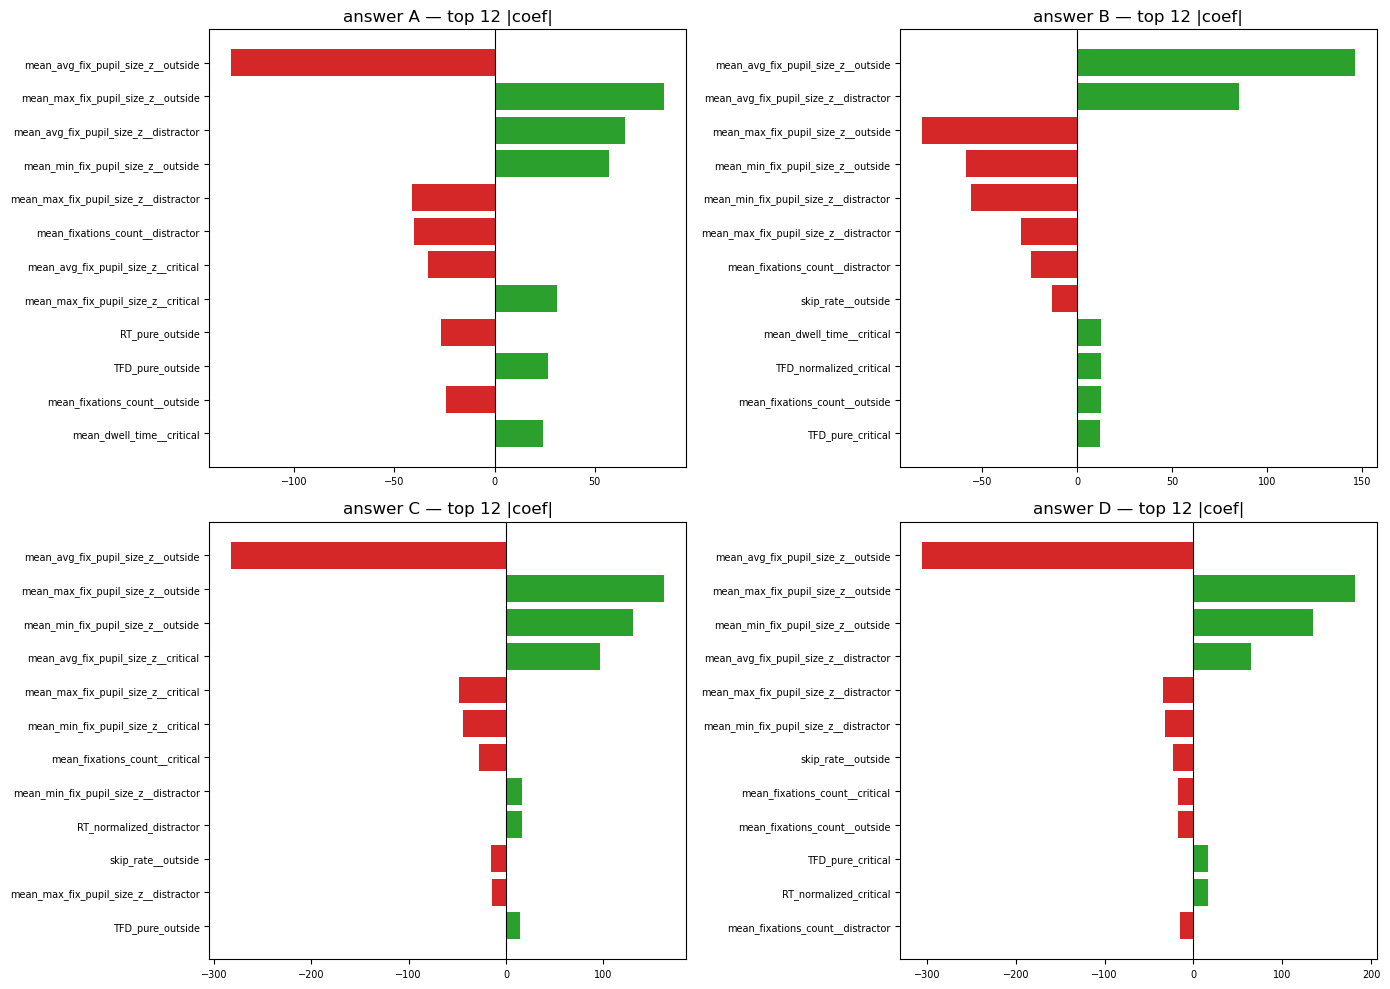

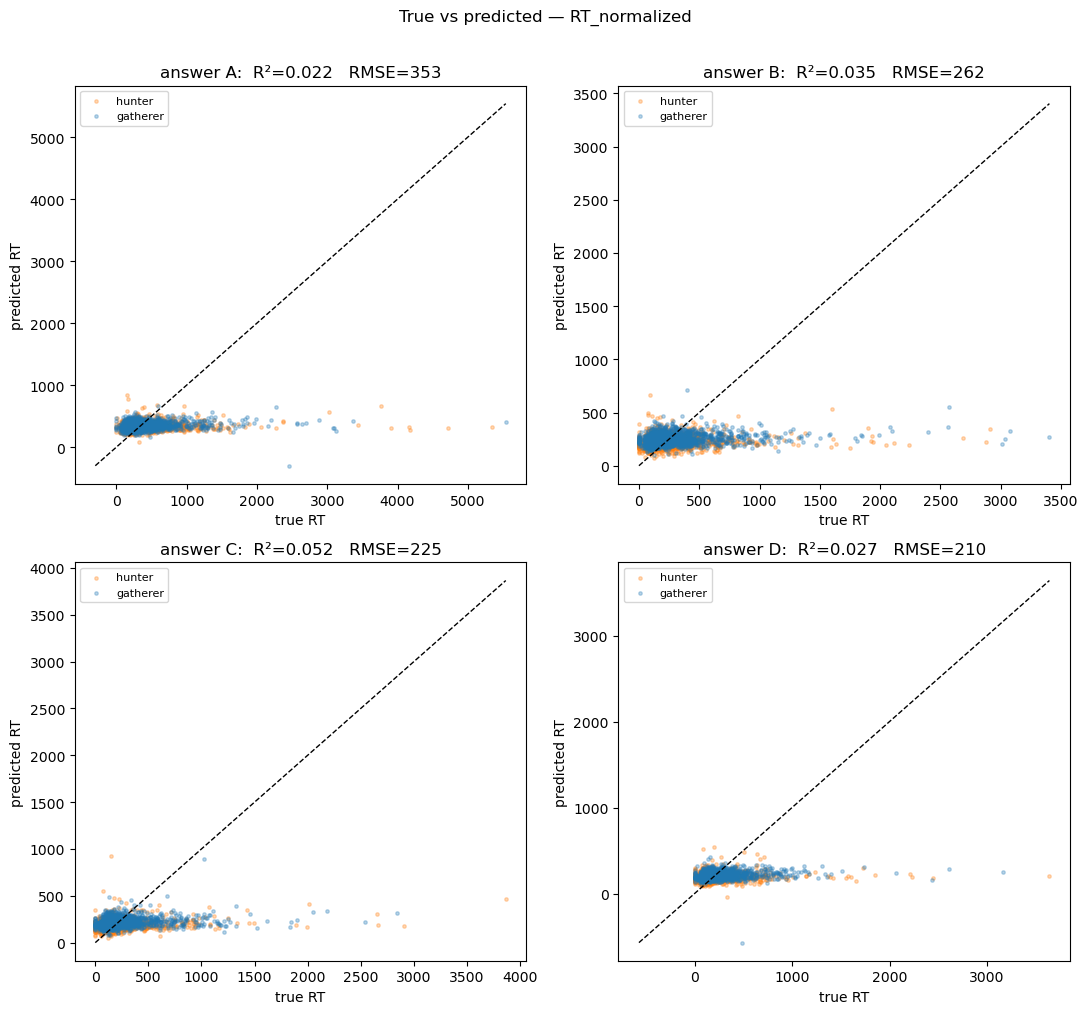

In [10]:
out_answer_rt = run_answer_rt_regression(
    model_df=answer_rt_model_df,
    feature_cols=FEATURE_COLS,
    rt_metric="RT_normalized",   # target: RT_normalized_answer_{A..D} ("RT_pure" also available)
    model_kind="ridge",          # "ridge" or "linear"
    alpha=1.0,
    test_size=0.2,
    random_state=42,
)

# per-answer held-out metrics
display(out_answer_rt["metrics"].round(3))

# coefficients and true/predicted
plot_coefs(out_answer_rt)
plot_true_pred(out_answer_rt)